In [2]:
from google.colab import files

uploaded = files.upload()

Saving task1_input.txt to task1_input.txt


In [4]:
import torch
import torch.nn as nn
from torch.nn import functional as F

batch_size = 64
block_size = 64
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4

device = 'cuda' if torch.cuda.is_available() else 'cpu'

eval_iters = 200

n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.2

with open('task1_input.txt', 'r', encoding='utf-8') as f:
    text = f.read() #read the text

chars = sorted(list(set(text))) #set gives unique chars, sorted sorts the list in alphabetical order
vocab_size = len(chars)

#tokenizer
stoi = { ch:i for i,ch in enumerate(chars) } #numerical mapping from str to int
itos = { i:ch for i,ch in enumerate(chars) } #reverse mapping

#encode/decode the text
encode = lambda s:[stoi[c] for c in s]
decode = lambda l:''.join([itos[i] for i in l])

#encode the entire dataset
data = torch.tensor(encode(text),dtype = torch.long)

#train/test split
n = int(0.9 * len(data))
train_data = data[:n] #first 900 elements
val_data = data[n:] #last 100 elements

def get_batch(split):
  data = train_data if split == 'train' else val_data
  ix = torch.randint(len(data)-block_size , (batch_size,))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  x,y = x.to(device),y.to(device)
  return x,y

class Head(nn.Module):

    def __init__(self, n_embd, head_size, block_size):

        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)

        self.query = nn.Linear(n_embd, head_size, bias=False)

        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size)) #causal mask matrix
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

      B, T, C = x.shape

      k = self.key(x)

      q = self.query(x)

      v = self.value(x)

      wei = q @ k.transpose(-2, -1) #attention score computation

      wei = wei * (k.size(-1) ** -0.5) # scale by 1/sqrt(d_k) to keep the attention scores in range
      wei = wei.masked_fill(
      self.tril[:T, :T] == 0, float("-inf")
      )
      wei = F.softmax(wei, dim=-1)
      wei = self.dropout(wei)# (B, T, T)
      # weighted sum of values
      out = wei @ v # (B, T, head_size)
      return out

class MultiHeadAttention(nn.Module):

    def __init__(self, n_embd, n_head, head_size, block_size):

        super().__init__()

        self.heads = nn.ModuleList([
            Head(n_embd, head_size, block_size)
            for _ in range(n_head)
        ])

        self.proj = nn.Linear(
            n_head * head_size,
            n_embd
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )

        out = self.dropout(self.proj(out))

        return out

class FeedForward(nn.Module):

    def __init__(self, n_embd):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(n_embd, 4 * n_embd),

            nn.ReLU(),

            nn.Linear(4 * n_embd, n_embd),

            nn.Dropout(dropout)
        )

    def forward(self, x):

        return self.net(x)


class Block(nn.Module):

    def __init__(self, n_embd, n_head, block_size):

        super().__init__()

        head_size = n_embd // n_head

        self.attn = MultiHeadAttention(
            n_embd,
            n_head,
            head_size,
            block_size
        )

        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)

        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        x = x + self.attn(self.ln1(x))

        x = x + self.ffwd(self.ln2(x))

        return x


class TransformerLanguageModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )

        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )

        self.blocks = nn.Sequential(
            *[Block(n_embd, n_head, block_size)
              for _ in range(n_layer)]
        )

        self.ln_f = nn.LayerNorm(n_embd)

        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):

        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)

        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)
        )

        x = tok_emb + pos_emb

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        if targets is None:

            loss = None

        else:

            B, T, C = logits.shape

            logits = logits.view(B*T, C)

            targets = targets.view(B*T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):

        for _ in range(max_new_tokens):

            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :]

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(
                probs,
                num_samples=1
            )

            idx = torch.cat((idx, idx_next), dim=1)

        return idx

model = TransformerLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)

  #Training loop
train_losses = []
for iter in range(max_iters):
  xb,yb = get_batch('train')
  logits,loss = model(xb,yb)
  optimizer.zero_grad(set_to_none = True)
  loss.backward() #backpropogation
  optimizer.step() #changes the weights to optimize the model

  if iter%eval_interval == 0:
    print(loss.item()) #print the loss after every 300 iterations
    train_losses.append(loss.item())

context = torch.zeros((1,1),dtype = torch.long, device = device)
print(decode(model.generate(context, max_new_tokens=500)[0].tolist())) #generate the encdoings and decode for us to see
torch.save(train_losses, "baseline_losses.pt")


4.3341522216796875
2.2904655933380127
2.019068717956543
1.986055612564087
1.9257043600082397
1.7959227561950684
1.7281990051269531
1.686163306236267
1.614770770072937
1.6928209066390991

Farewell ther news pacled of hing.

CLAEXENDY ANNES:
No dost: think, not poin the cunteo's le'et
But me from my not should; then clown you'ldows bess.
See prove we untello!
Then
The disshinks' thee, if Lord Nament my heads thanded
But a that him hour,--

CORTHUMBERLANUS:
Holdie other be that insman. He do meet.

QUEEN ELIZABRUTRD:
To do mean: y sart, my would to Here in the press,
and take valentress, it the more of not
Go-lood a weart'd and of leavene up?
Tray to it, smay of the our their Round


In [5]:
#ABLATION EXPERIMENT 2
import torch
import torch.nn as nn
from torch.nn import functional as F

batch_size = 64
block_size = 64
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4

device = 'cuda' if torch.cuda.is_available() else 'cpu'

eval_iters = 200

n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.2

with open('task1_input.txt', 'r', encoding='utf-8') as f:
    text = f.read() #read the text

chars = sorted(list(set(text))) #set gives unique chars, sorted sorts the list in alphabetical order
vocab_size = len(chars)

#tokenizer
stoi = { ch:i for i,ch in enumerate(chars) } #numerical mapping from str to int
itos = { i:ch for i,ch in enumerate(chars) } #reverse mapping

#encode/decode the text
encode = lambda s:[stoi[c] for c in s]
decode = lambda l:''.join([itos[i] for i in l])

#encode the entire dataset
data = torch.tensor(encode(text),dtype = torch.long)

#train/test split
n = int(0.9 * len(data))
train_data = data[:n] #first 900 elements
val_data = data[n:] #last 100 elements

def get_batch(split):
  data = train_data if split == 'train' else val_data
  ix = torch.randint(len(data)-block_size , (batch_size,))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  x,y = x.to(device),y.to(device)
  return x,y

class Head(nn.Module):

    def __init__(self, n_embd, head_size, block_size):

        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)

        self.query = nn.Linear(n_embd, head_size, bias=False)

        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size)) #causal mask matrix
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

      B, T, C = x.shape

      k = self.key(x)

      q = self.query(x)

      v = self.value(x)

      wei = q @ k.transpose(-2, -1) #attention score computation

      wei = wei * (k.size(-1) ** -0.5) # scale by 1/sqrt(d_k) to keep the attention scores in range
      wei = wei.masked_fill(
      self.tril[:T, :T] == 0, float("-inf")
      )
      wei = F.softmax(wei, dim=-1)
      wei = self.dropout(wei)# (B, T, T)
      # weighted sum of values
      out = wei @ v # (B, T, head_size)
      return out

class MultiHeadAttention(nn.Module):

    def __init__(self, n_embd, n_head, head_size, block_size):

        super().__init__()

        self.heads = nn.ModuleList([
            Head(n_embd, head_size, block_size)
            for _ in range(n_head)
        ])

        self.proj = nn.Linear(
            n_head * head_size,
            n_embd
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )

        out = self.dropout(self.proj(out))

        return out

class FeedForward(nn.Module):

    def __init__(self, n_embd):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(n_embd, 4 * n_embd),

            nn.ReLU(),

            nn.Linear(4 * n_embd, n_embd),

            nn.Dropout(dropout)
        )

    def forward(self, x):

        return self.net(x)


class Block(nn.Module):

    def __init__(self, n_embd, n_head, block_size):

        super().__init__()

        head_size = n_embd // n_head

        self.attn = MultiHeadAttention(
            n_embd,
            n_head,
            head_size,
            block_size
        )

        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)

        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):


        x = self.attn(self.ln1(x))

        x = self.ffwd(self.ln2(x))

        return x


class TransformerLanguageModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )

        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )

        self.blocks = nn.Sequential(
            *[Block(n_embd, n_head, block_size)
              for _ in range(n_layer)]
        )

        self.ln_f = nn.LayerNorm(n_embd)

        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):

        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)

        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)
        )

        x = tok_emb + pos_emb

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        if targets is None:

            loss = None

        else:

            B, T, C = logits.shape

            logits = logits.view(B*T, C)

            targets = targets.view(B*T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):

        for _ in range(max_new_tokens):

            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :]

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(
                probs,
                num_samples=1
            )

            idx = torch.cat((idx, idx_next), dim=1)

        return idx

model = TransformerLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)

  #Training loop
train_losses = []
for iter in range(max_iters):
  xb,yb = get_batch('train')
  logits,loss = model(xb,yb)
  optimizer.zero_grad(set_to_none = True)
  loss.backward() #backpropogation
  optimizer.step() #changes the weights to optimize the model

  if iter%eval_interval == 0:
    print(loss.item()) #print the loss after every 300 iterations
    train_losses.append(loss.item())

context = torch.zeros((1,1),dtype = torch.long, device = device)
print(decode(model.generate(context, max_new_tokens=500)[0].tolist())) #generate the encdoings and decode for us to see
torch.save(train_losses, "no_residual_losses.pt")


4.403291702270508
3.276580810546875
3.227574110031128
3.2349021434783936
3.3179495334625244
3.2105214595794678
3.1030309200286865
3.059300184249878
2.9413533210754395
2.8685057163238525

Sfawiodsl as s br: Rme,
Bofh yer ;
Tit Pntate me,
ORAdc helt imen s!
Tomhonynl s foss meuedie g wedshedetairob tedtbe b w th.
Iydge hhu gn te'de aasorso s y llde, Ns bir sin nouatho nordoerC vhaer,
Hed t uat neatjes; yl, n;
W r mhothon'es heag ndu! b f tuelofarowico n g. afper sdhowiusoth l;
Woriutimo? n DUARAy diwou nsaWot, telagot athh, thou te s Rtu hertenoayaesd.
Tubithhertrld f url
I ILomirev ter lpyaf nen riM tet!teds gusy imweiataendya mate tneno- r lo uex p it th: be hol yd mato, n fhote


In [6]:
import torch
import torch.nn as nn
from torch.nn import functional as F

batch_size = 64
block_size = 64
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4

device = 'cuda' if torch.cuda.is_available() else 'cpu'

eval_iters = 200

n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.2

with open('task1_input.txt', 'r', encoding='utf-8') as f:
    text = f.read() #read the text

chars = sorted(list(set(text))) #set gives unique chars, sorted sorts the list in alphabetical order
vocab_size = len(chars)

#tokenizer
stoi = { ch:i for i,ch in enumerate(chars) } #numerical mapping from str to int
itos = { i:ch for i,ch in enumerate(chars) } #reverse mapping

#encode/decode the text
encode = lambda s:[stoi[c] for c in s]
decode = lambda l:''.join([itos[i] for i in l])

#encode the entire dataset
data = torch.tensor(encode(text),dtype = torch.long)

#train/test split
n = int(0.9 * len(data))
train_data = data[:n] #first 900 elements
val_data = data[n:] #last 100 elements

def get_batch(split):
  data = train_data if split == 'train' else val_data
  ix = torch.randint(len(data)-block_size , (batch_size,))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  x,y = x.to(device),y.to(device)
  return x,y

class Head(nn.Module):

    def __init__(self, n_embd, head_size, block_size):

        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)

        self.query = nn.Linear(n_embd, head_size, bias=False)

        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size)) #causal mask matrix
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

      B, T, C = x.shape

      k = self.key(x)

      q = self.query(x)

      v = self.value(x)

      wei = q @ k.transpose(-2, -1) #attention score computation

      wei = wei * (k.size(-1) ** -0.5) # scale by 1/sqrt(d_k) to keep the attention scores in range
      wei = wei.masked_fill(
      self.tril[:T, :T] == 0, float("-inf")
      )
      wei = F.softmax(wei, dim=-1)
      wei = self.dropout(wei)# (B, T, T)
      # weighted sum of values
      out = wei @ v # (B, T, head_size)
      return out

class MultiHeadAttention(nn.Module):

    def __init__(self, n_embd, n_head, head_size, block_size):

        super().__init__()

        self.heads = nn.ModuleList([
            Head(n_embd, head_size, block_size)
            for _ in range(n_head)
        ])

        self.proj = nn.Linear(
            n_head * head_size,
            n_embd
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )

        out = self.dropout(self.proj(out))

        return out

class FeedForward(nn.Module):

    def __init__(self, n_embd):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(n_embd, 4 * n_embd),

            nn.ReLU(),

            nn.Linear(4 * n_embd, n_embd),

            nn.Dropout(dropout)
        )

    def forward(self, x):

        return self.net(x)


class Block(nn.Module):

    def __init__(self, n_embd, n_head, block_size):

        super().__init__()

        head_size = n_embd // n_head

        self.attn = MultiHeadAttention(
            n_embd,
            n_head,
            head_size,
            block_size
        )

        self.ffwd = FeedForward(n_embd)

    def forward(self, x):

        x = x + self.attn(x)

        x = x + self.ffwd(x)

        return x


class TransformerLanguageModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )

        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )

        self.blocks = nn.Sequential(
            *[Block(n_embd, n_head, block_size)
              for _ in range(n_layer)]
        )

        self.ln_f = nn.LayerNorm(n_embd)

        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):

        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)

        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)
        )

        x = tok_emb + pos_emb

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        if targets is None:

            loss = None

        else:

            B, T, C = logits.shape

            logits = logits.view(B*T, C)

            targets = targets.view(B*T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):

        for _ in range(max_new_tokens):

            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :]

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(
                probs,
                num_samples=1
            )

            idx = torch.cat((idx, idx_next), dim=1)

        return idx

model = TransformerLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)

  #Training loop
train_losses = []
for iter in range(max_iters):
  xb,yb = get_batch('train')
  logits,loss = model(xb,yb)
  optimizer.zero_grad(set_to_none = True)
  loss.backward() #backpropogation
  optimizer.step() #changes the weights to optimize the model

  if iter%eval_interval == 0:
    print(loss.item()) #print the loss after every 300 iterations
    train_losses.append(loss.item())

context = torch.zeros((1,1),dtype = torch.long, device = device)
print(decode(model.generate(context, max_new_tokens=500)[0].tolist())) #generate the encdoings and decode for us to see
torch.save(train_losses, "no_ln_losses.pt")


4.423846244812012
2.2276694774627686
1.9560545682907104
1.8550246953964233
1.7833707332611084
1.7464890480041504
1.7007704973220825
1.695696234703064
1.6547632217407227
1.6387698650360107

Ned the king? Durcy'd my name not himself
Here, led'st give the diever; I duly nuty alore than neproforb.

POLINISAS:
How Laror, no kill!
O, yet the grief in eysance,
What is he disstry held tose, and look; but shame to.

Jorse:
Be remore ince your prove, as not them lable.

WARDICK:
Wiltho read by nour a noine wifters breking.
Knot Edw for carenest tar wer violring, come, of think,
And bete it To time of threse his northle plake?

EFirsand Most:
My one, see
The king pauch'd and Parrean; Edward 


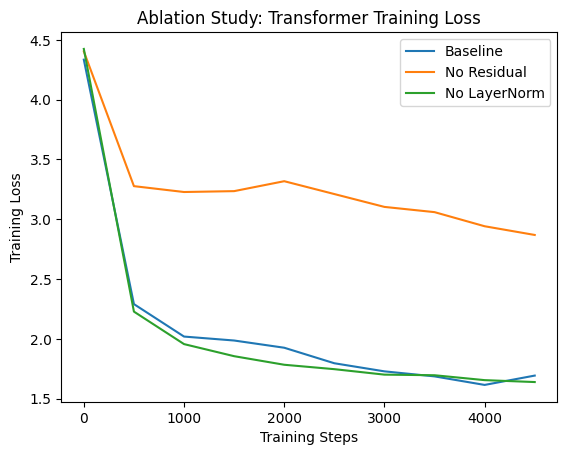

In [7]:
import torch
import matplotlib.pyplot as plt

baseline = torch.load("baseline_losses.pt")
no_res = torch.load("no_residual_losses.pt")
no_ln = torch.load("no_ln_losses.pt")

steps = range(0, 5000, 500)

plt.plot(steps, baseline, label='Baseline')
plt.plot(steps, no_res, label='No Residual')
plt.plot(steps, no_ln, label='No LayerNorm')

plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.title("Ablation Study: Transformer Training Loss")
plt.legend()

plt.show()

**Baseline:**
The baseline model showed the best and most stable convergence, with the training loss decreasing smoothly from about 4.4 to 1.65. This is expected because residual connections provide direct paths for gradients to flow through the network, while LayerNorm stabilizes activations and prevents large variations during training.

**No Residual Connections:**
Removing residual connections significantly hurt performance, with the loss plateauing around 2.9 and failing to converge to the baseline. Without residual shortcuts, gradients must pass through every layer sequentially, making them more prone to vanishing and resulting in slower and less effective learning.

**No LayerNorm:**
Surprisingly, removing the LayerNorm layers inside each transformer block did not degrade performance and even resulted in a slightly lower training loss. However, since a final LayerNorm layer was still present and the model was relatively shallow (4 layers), this result does not imply that LayerNorm is unnecessary. Rather, it suggests that for small transformer models, residual connections play a more significant role in maintaining effective gradient flow than block-level LayerNorms.
